In [ ]:
!pip install -q -U google-genai pandas scikit-learn sentence-transformers umap-learn hdbscan tqdm wordcloud squarify networkx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.9/750.9 kB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 268.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 199.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, bu

In [ ]:
from google.colab import drive
import os
import shutil
import glob

drive.mount('/content/drive')

drive_path = '/content/drive/My Drive/LLooM_ops_non_stigma'

Mounted at /content/drive


In [ ]:
if os.path.exists(drive_path):
    files_to_download = glob.glob(os.path.join(drive_path, '*'))

    print(f"📥 Found {len(files_to_download)} files in Drive. Starting download...")

    downloaded_files = []
    for file_path in files_to_download:
        fname = os.path.basename(file_path)
        try:
            shutil.copy2(file_path, os.path.join('/content/lloom_gemini_sv_outputs_nonstigma', fname))
            downloaded_files.append(fname)
        except Exception as e:
            print(f"❌ Error downloading {fname}: {e}")
    print("\n" + "="*40)
    print(f"✅ DOWNLOAD COMPLETE: {len(downloaded_files)} files restored")
    print("="*40)

    for i, name in enumerate(sorted(downloaded_files), 1):
        print(f"{i}. {name}")
else:
    print(f"⚠️ Folder not found: {drive_path}. Check your path name.")

📥 Found 16 files in Drive. Starting download...

✅ DOWNLOAD COMPLETE: 16 files restored
1. non_stigma_post_concept_summary.csv
2. non_stigma_post_concepts.csv
3. non_stigma_post_concepts.pdf
4. non_stigma_post_concepts_table.csv
5. non_stigma_post_score_checkpoint.jsonl
6. non_stigma_post_scores.csv
7. non_stigma_posts_distill_checkpoint.jsonl
8. non_stigma_posts_distilled_bullets.csv
9. non_stigma_support_concept_summary.csv
10. non_stigma_support_concepts.csv
11. non_stigma_support_concepts.pdf
12. non_stigma_support_concepts_table.csv
13. non_stigma_support_distill_checkpoint.jsonl
14. non_stigma_support_distilled_bullets.csv
15. non_stigma_support_score_checkpoint.jsonl
16. non_stigma_support_scores.csv


#Imports

In [ ]:
import re
import json
import time
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

from google.genai import types

from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from wordcloud import WordCloud
import squarify
import networkx as nx

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [ ]:
import json
import pandas as pd
from google.cloud import storage
from google.cloud import aiplatform
import os

In [ ]:
import os
from google.colab import auth

auth.authenticate_user()
os.environ["GOOGLE_CLOUD_API_KEY"] = "YOUR_API_KEY"

In [ ]:
from google import genai


PROJECT_ID = "gen-lang-client-0150300232"
LOCATION = "us-central1"  # Vertex AI requires a specific region

aiplatform.init(
    project=PROJECT_ID,
    location=LOCATION,
)

client = genai.Client(
    vertexai=True,
    project=PROJECT_ID,
    location=LOCATION
)

response = client.models.generate_content(
    model="gemini-2.0-flash",
    contents="Hello!"
)

print(response.text)

Hello! How can I help you today?



# Load stigma and support datasets

In [ ]:
NON_STIGMA_SUPPORT_PATH = "/content/no_stigma_support_predictions.csv"

POST_COL = "body"
COMMENT_COL = "comment_text"

OUTPUT_DIR = "/content/lloom_gemini_sv_outputs_nonstigma"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# Models
# =========================
MODEL_FLASH = "gemini-2.0-flash"

MODEL_DISTILL = MODEL_FLASH
MODEL_SYNTH   = MODEL_FLASH
MODEL_SCORE   = MODEL_FLASH

# =========================
# Sexual violence seed phrases
# =========================
NON_STIGMA_SEED = "non-stigmatizing sexual violence-related Reddit narratives, including descriptions of experiences, advice-seeking, and discussion without explicit blame, shame, fear of judgment, or social invalidation"

SUPPORT_SEED = "types of emotional, informational, practical, and community-based support in sexual violence-related Reddit discussions"

print("Output dir:", OUTPUT_DIR)
print("Using model:", MODEL_FLASH)
print("Non-stigma seed:", NON_STIGMA_SEED)
print("Support seed:", SUPPORT_SEED)

non_stigma_df = pd.read_csv(NON_STIGMA_SUPPORT_PATH)

print("Non-stigma shape:", non_stigma_df.shape)
display(non_stigma_df.head())

Output dir: /content/lloom_gemini_sv_outputs_nonstigma
Using model: gemini-2.0-flash
Non-stigma seed: non-stigmatizing sexual violence-related Reddit narratives, including descriptions of experiences, advice-seeking, and discussion without explicit blame, shame, fear of judgment, or social invalidation
Support seed: types of emotional, informational, practical, and community-based support in sexual violence-related Reddit discussions
Non-stigma shape: (1175, 13)


,body,l2_json,l2_label,l2_reason,l2_evidence,post_id,comment_id,comment_author,comment_text,comment_score,comment_created_utc,support_json,support_labels
0,"So, to make a long story short, my mom will gr...","{'label': 'No Stigma', 'reason': 'The post des...",No Stigma,The post describes potential sexual harassment...,NaN,ojp7lk,h539sfg,queenrothko,You’re not being dramatic at all. You’ve told ...,4,1626216078,"{""label_presence"": {""Information Support"": tru...","Information Support, Emotional Support, Esteem..."
1,"So, to make a long story short, my mom will gr...","{'label': 'No Stigma', 'reason': 'The post des...",No Stigma,The post describes potential sexual harassment...,NaN,ojp7lk,h54ufu8,indyradmama,More like sexual assault!! you have every rig...,5,1626252279,"{""label_presence"": {""Information Support"": tru...","Information Support, Emotional Support, Esteem..."
2,"So, to make a long story short, my mom will gr...","{'label': 'No Stigma', 'reason': 'The post des...",No Stigma,The post describes potential sexual harassment...,NaN,ojp7lk,h54zdn2,[deleted],"If she tries doing this again, attack her or f...",1,1626256899,"{""label_presence"": {""Information Support"": tru...","Information Support, Emotional Support, Esteem..."
3,Earlier today at school I experienced unwanted...,"{'label': 'No Stigma', 'reason': 'The post des...",No Stigma,The post describes an experience of unwanted t...,NaN,o79e7h,h2xdoq5,Acceptable_Copy933,It’s okay to dm me,4,1624567183,"{""label_presence"": {""Information Support"": fal...",Tangible Assistance
4,Earlier today at school I experienced unwanted...,"{'label': 'No Stigma', 'reason': 'The post des...",No Stigma,The post describes an experience of unwanted t...,NaN,o79e7h,h2xd7ht,[deleted],[deleted],3,1624566955,"{""label_presence"": {""Information Support"": fal...",NaN


# Text Cleaning

In [ ]:
def clean_text(x):
    x = str(x).lower().strip()
    x = re.sub(r"http\S+|www\S+", " ", x)
    x = re.sub(r"&amp;|amp", " ", x)
    x = re.sub(r">+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

# Keep only non-stigma rows if needed
non_stigma_df = non_stigma_df[non_stigma_df["l2_label"] == "No Stigma"].copy()

# -------------------------
# Posts dataframe
# -------------------------
non_stigma_posts_df = non_stigma_df.dropna(subset=[POST_COL]).copy()
non_stigma_posts_df["clean_text"] = non_stigma_posts_df[POST_COL].astype(str).apply(clean_text)
non_stigma_posts_df = non_stigma_posts_df[
    non_stigma_posts_df["clean_text"].str.strip() != ""
].copy()

# -------------------------
# Support/comments dataframe
# -------------------------
non_stigma_support_df = non_stigma_df.dropna(subset=[COMMENT_COL]).copy()
non_stigma_support_df["clean_text"] = non_stigma_support_df[COMMENT_COL].astype(str).apply(clean_text)
non_stigma_support_df = non_stigma_support_df[
    non_stigma_support_df["clean_text"].str.strip() != ""
].copy()

print("After cleaning:")
print("non_stigma_posts_df:", non_stigma_posts_df.shape)
print("non_stigma_support_df:", non_stigma_support_df.shape)

After cleaning:
non_stigma_posts_df: (1175, 14)
non_stigma_support_df: (1174, 14)


In [ ]:
bot_patterns = [
    "if you or someone you know is contemplating suicide",
    "please reach out to",
    "reddit help resources",
    "this post has been removed",
    "contact the moderators",
    "subreddit rules",
    "performed automatically",
    "i am a bot",
    "was performed automatically"
]

bot_regex = "|".join(bot_patterns)

non_stigma_support_df = non_stigma_support_df[
    ~non_stigma_support_df["clean_text"].str.contains(bot_regex, case=False, na=False)
].copy()

print("After bot/mod filtering:")
print("non_stigma_posts_df:", non_stigma_posts_df.shape)
print("non_stigma_support_df:", non_stigma_support_df.shape)

After bot/mod filtering:
non_stigma_posts_df: (1175, 14)
non_stigma_support_df: (1147, 14)


In [ ]:
def safe_json_load(text):
    text = str(text).strip()

    text = re.sub(r"^```json\s*", "", text)
    text = re.sub(r"^```\s*", "", text)
    text = re.sub(r"\s*```$", "", text)

    try:
        return json.loads(text)
    except Exception:
        pass

    m = re.search(r"\{.*\}", text, re.DOTALL)
    if m:
        return json.loads(m.group(0))

    raise ValueError(f"Could not parse JSON from response:\n{text[:1200]}")

In [ ]:
def gemini_json(prompt, model_name, temperature=0.2):
    response = client.models.generate_content(
        model=model_name,
        contents=prompt,
        config=types.GenerateContentConfig(
            temperature=temperature,
            response_mime_type="application/json"
        )
    )
    return safe_json_load(response.text)

# Distill one text into 2–4 short bullets

In [ ]:
def distill_text_to_bullets(text, seed_phrase=""):
    prompt = f"""
You will read one Reddit text and summarize its main points into 2 to 4 short bullet phrases.

Rules:
- Each bullet must be 5 to 10 words
- Focus on the most salient meaning
- Avoid generic phrases
- Avoid repeating the same idea
- Keep wording concise
- Use the analytic focus only as a lens, not as a reason to invent content
- Return valid JSON only

Analytic focus:
{seed_phrase if seed_phrase else "None"}

Return format:
{{
  "bullets": ["...", "..."]
}}

TEXT:
{text}
"""
    obj = gemini_json(prompt, MODEL_DISTILL, temperature=0.2)
    bullets = obj.get("bullets", [])
    bullets = [str(b).strip() for b in bullets if str(b).strip()]
    return bullets[:4]

In [ ]:
def _distill_one(idx, txt, seed_phrase="", max_retries=3, sleep_seconds=2):
    for attempt in range(max_retries):
        try:
            bullets = distill_text_to_bullets(txt, seed_phrase=seed_phrase)
            return {
                "orig_index": idx,
                "text": txt,
                "bullets": bullets,
                "error": None
            }
        except Exception as e:
            err = str(e)
            if attempt < max_retries - 1:
                time.sleep(sleep_seconds * (attempt + 1))
            else:
                return {
                    "orig_index": idx,
                    "text": txt,
                    "bullets": None,
                    "error": err
                }

def run_distillation_parallel_checkpointed(
    df,
    text_col="clean_text",
    sample_limit=None,
    seed_phrase="",
    max_workers=4,
    max_retries=3,
    checkpoint_path="distill_checkpoint.jsonl"
):
    rows = []
    done_ids = set()

    if os.path.exists(checkpoint_path):
        with open(checkpoint_path, "r") as f:
            for line in f:
                rec = json.loads(line)
                rows.append(rec)
                done_ids.add(rec["orig_index"])

    work_df = df.copy()
    if sample_limit is not None:
        work_df = work_df.sample(sample_limit, random_state=42)

    items = [
        (idx, row[text_col])
        for idx, row in work_df.iterrows()
        if idx not in done_ids
    ]

    print(f"Already completed: {len(done_ids)}")
    print(f"Remaining: {len(items)}")

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {
            executor.submit(_distill_one, idx, txt, seed_phrase, max_retries): idx
            for idx, txt in items
        }

        with open(checkpoint_path, "a") as fout:
            for fut in tqdm(as_completed(futures), total=len(futures), desc="Distilling"):
                result = fut.result()
                fout.write(json.dumps(result) + "\n")
                fout.flush()
                rows.append(result)

    return pd.DataFrame(rows)

In [ ]:
non_stigma_posts_distilled_raw = run_distillation_parallel_checkpointed(
    non_stigma_posts_df,
    text_col="clean_text",
    sample_limit=None,
    seed_phrase=NON_STIGMA_SEED,
    max_workers=4,
    checkpoint_path=f"{OUTPUT_DIR}/non_stigma_posts_distill_checkpoint.jsonl"
)

non_stigma_support_distilled_raw = run_distillation_parallel_checkpointed(
    non_stigma_support_df,
    text_col="clean_text",
    sample_limit=None,
    seed_phrase=SUPPORT_SEED,
    max_workers=4,
    checkpoint_path=f"{OUTPUT_DIR}/non_stigma_support_distill_checkpoint.jsonl"
)

print("non_stigma_posts_distilled_raw:", non_stigma_posts_distilled_raw.shape)
print("non_stigma_support_distilled_raw:", non_stigma_support_distilled_raw.shape)

Already completed: 1175
Remaining: 0


Distilling: 0it [00:00, ?it/s]

Already completed: 1147
Remaining: 0


Distilling: 0it [00:00, ?it/s]

non_stigma_posts_distilled_raw: (1175, 4)
non_stigma_support_distilled_raw: (1147, 4)


In [ ]:
print(non_stigma_posts_distilled_raw.columns.tolist())
print(non_stigma_support_distilled_raw.columns.tolist())

print("\nPOST sample bullets values:")
for i, v in enumerate(non_stigma_posts_distilled_raw["bullets"].head(5)):
    print(f"{i}: type={type(v)} | value={repr(v)[:500]}")

print("\nSUPPORT sample bullets values:")
for i, v in enumerate(non_stigma_support_distilled_raw["bullets"].head(5)):
    print(f"{i}: type={type(v)} | value={repr(v)[:500]}")

['orig_index', 'text', 'bullets', 'error']
['orig_index', 'text', 'bullets', 'error']

POST sample bullets values:
0: type=<class 'list'> | value=['Student experienced unwanted touching at school today.', 'Girl squeezed their thigh and leg without consent.', 'Asks for advice on how to handle the situation.']
1: type=<class 'list'> | value=["Mother gropes daughters' breasts and buttocks weekly.", 'Daughters tell mother to stop, but she continues.', 'Mother claims she does it to annoy them.', 'Daughter asks if this is sexual harassment.']
2: type=<class 'list'> | value=["Mother gropes daughters' breasts and buttocks weekly.", 'Daughters tell her to stop, but she continues.', 'Mother claims she does it to annoy them.', 'Daughter asks if this is sexual harassment.']
3: type=<class 'list'> | value=["Mother gropes daughters weekly, claims it's to annoy them", 'Daughters tell her to stop, but she continues', 'Daughter asks if this counts as sexual harassment']
4: type=<class 'list'> | value=[

In [ ]:
print("Post errors:", non_stigma_posts_distilled_raw["error"].notna().sum())
print("Support errors:", non_stigma_support_distilled_raw["error"].notna().sum())

display(non_stigma_posts_distilled_raw[["orig_index", "error"]].head(10))
display(non_stigma_support_distilled_raw[["orig_index", "error"]].head(10))

Post errors: 0
Support errors: 0


,orig_index,error
0,3,None
1,2,None
2,1,None
3,0,None
4,4,None
5,7,None
6,5,None
7,6,None
8,8,None
9,9,None


,orig_index,error
0,3,None
1,1,None
2,0,None
3,2,None
4,4,None
5,7,None
6,6,None
7,5,None
8,8,None
9,10,None


In [ ]:
def expand_distilled_rows(distilled_df):
    rows = []

    for _, row in distilled_df.iterrows():
        bullets = row.get("bullets")

        # Handle stringified lists from checkpoint/json
        if isinstance(bullets, str):
            bullets = bullets.strip()
            if bullets:
                try:
                    bullets = json.loads(bullets)
                except Exception:
                    try:
                        import ast
                        bullets = ast.literal_eval(bullets)
                    except Exception:
                        bullets = None

        if isinstance(bullets, list):
            for b in bullets:
                b = str(b).strip()
                if b:
                    rows.append({
                        "orig_index": row["orig_index"],
                        "text": row["text"],
                        "bullet": b,
                        "error": row.get("error")
                    })
        else:
            rows.append({
                "orig_index": row["orig_index"],
                "text": row["text"],
                "bullet": None,
                "error": row.get("error")
            })

    return pd.DataFrame(rows)

non_stigma_posts_distilled = expand_distilled_rows(non_stigma_posts_distilled_raw)
non_stigma_support_distilled = expand_distilled_rows(non_stigma_support_distilled_raw)

non_stigma_posts_distilled = non_stigma_posts_distilled.dropna(subset=["bullet"]).copy()
non_stigma_support_distilled = non_stigma_support_distilled.dropna(subset=["bullet"]).copy()

print("Expanded non-stigma post bullets:", non_stigma_posts_distilled.shape)
print("Expanded non-stigma support bullets:", non_stigma_support_distilled.shape)

non_stigma_posts_distilled.to_csv(
    f"{OUTPUT_DIR}/non_stigma_posts_distilled_bullets.csv", index=False
)
non_stigma_support_distilled.to_csv(
    f"{OUTPUT_DIR}/non_stigma_support_distilled_bullets.csv", index=False
)

Expanded non-stigma post bullets: (3892, 4)
Expanded non-stigma support bullets: (2959, 4)


In [ ]:
embedder = SentenceTransformer("all-mpnet-base-v2")

non_stigma_post_bullets = non_stigma_posts_distilled["bullet"].tolist()
non_stigma_support_bullets = non_stigma_support_distilled["bullet"].tolist()

non_stigma_post_emb = embedder.encode(non_stigma_post_bullets, show_progress_bar=True)
non_stigma_support_emb = embedder.encode(non_stigma_support_bullets, show_progress_bar=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/122 [00:00<?, ?it/s]

Batches:   0%|          | 0/93 [00:00<?, ?it/s]

# Clustering Distilled Bullets

In [ ]:
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

clusterer = HDBSCAN(
    min_cluster_size=12,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

non_stigma_post_red = umap_model.fit_transform(non_stigma_post_emb)
non_stigma_support_red = umap_model.fit_transform(non_stigma_support_emb)

non_stigma_post_labels = clusterer.fit_predict(non_stigma_post_red)
non_stigma_support_labels = clusterer.fit_predict(non_stigma_support_red)

non_stigma_posts_distilled["cluster"] = non_stigma_post_labels
non_stigma_support_distilled["cluster"] = non_stigma_support_labels

display(non_stigma_posts_distilled["cluster"].value_counts().head(20))
display(non_stigma_support_distilled["cluster"].value_counts().head(20))

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
-1     1302
 34     100
 66      89
 58      86
 49      78
 9       77
 68      77
 52      77
 18      75
 60      74
 19      63
 48      62
 14      61
 36      58
 56      51
 57      50
 37      45
 74      44
 31      42
 47      40
Name: count, dtype: int64

cluster
-1     1274
 20     133
 41     104
 15     104
 43      90
 16      82
 30      70
 42      62
 36      59
 28      48
 27      46
 1       43
 13      42
 17      40
 32      39
 29      39
 8       39
 5       38
 12      35
 38      34
Name: count, dtype: int64

In [ ]:
def show_cluster_examples(distilled_df, top_n_clusters=10, examples_per_cluster=8):
    counts = distilled_df[distilled_df["cluster"] != -1]["cluster"].value_counts().head(top_n_clusters)
    for cid in counts.index:
        print(f"\n===== CLUSTER {cid} | size={counts[cid]} =====")
        ex = distilled_df[distilled_df["cluster"] == cid]["bullet"].head(examples_per_cluster).tolist()
        for e in ex:
            print("-", e)

print("NON-STIGMA POST CLUSTERS")
show_cluster_examples(non_stigma_posts_distilled)

print("\nNON-STIGMA SUPPORT CLUSTERS")
show_cluster_examples(non_stigma_support_distilled)

NON-STIGMA POST CLUSTERS

===== CLUSTER 34 | size=100 =====
- Hearing unwanted sexual content from family member
- Woman recalls cousin's actions during her childhood.
- She seeks to understand the nature of cousin's actions.
- Childhood sexual exploration with brother caused discomfort.
- Aunt touched the narrator intimately in an Uber.
- Aunt touched the narrator inappropriately in an Uber
- Aunt touched the narrator inappropriately in an Uber
- Recollection of childhood incident with older girl

===== CLUSTER 66 | size=89 =====
- Assault survivor reports feeling emotionally numb
- The assault caused academic failure and basic self-care neglect.
- The assault caused academic failure and functional impairment.
- The assault caused academic failure and loss of dreams.
- The assault severely impacted the survivor's life.
- The assault severely impacted the survivor's life.
- The assault severely impacted survivor's life and goals.
- The assault severely impacted survivor's life and goal

In [ ]:
def synthesize_concept(cluster_bullets, seed_phrase=""):
    bullets_text = "\n".join([f"- {b}" for b in cluster_bullets])

    prompt = f"""
You are inducing a high-level concept from a set of short bullet summaries from Reddit posts/comments.

Your job:
1. Propose one specific, human-interpretable concept
2. Write explicit inclusion criteria for when a text matches this concept
3. Avoid generic labels like "general discussion" or "emotion"
4. Make the concept concise but meaningful
5. Return valid JSON only

Analytic focus:
{seed_phrase if seed_phrase else "None"}

Return format:
{{
  "concept_name": "...",
  "description": "...",
  "inclusion_criteria": "...",
  "example_signals": ["...", "...", "..."]
}}

BULLETS:
{bullets_text}
"""
    obj = gemini_json(prompt, MODEL_SYNTH, temperature=0.2)
    return obj

In [ ]:
def build_concepts_from_clusters(distilled_df, top_n_clusters=10, max_bullets_per_cluster=20, seed_phrase=""):
    concepts = []
    counts = distilled_df[distilled_df["cluster"] != -1]["cluster"].value_counts().head(top_n_clusters)

    for cid in tqdm(counts.index, desc="Synthesizing concepts"):
        bullets = distilled_df[distilled_df["cluster"] == cid]["bullet"].dropna().tolist()
        bullets = bullets[:max_bullets_per_cluster]

        try:
            concept = synthesize_concept(bullets, seed_phrase=seed_phrase)
            concept["cluster"] = int(cid)
            concept["cluster_size"] = int(counts[cid])
            concepts.append(concept)
        except Exception as e:
            concepts.append({
                "cluster": int(cid),
                "cluster_size": int(counts[cid]),
                "concept_name": None,
                "description": None,
                "inclusion_criteria": None,
                "example_signals": None,
                "error": str(e)
            })

    return pd.DataFrame(concepts)

In [ ]:
non_stigma_post_concepts = build_concepts_from_clusters(
    non_stigma_posts_distilled,
    top_n_clusters=10,
    max_bullets_per_cluster=20,
    seed_phrase=NON_STIGMA_SEED
)

non_stigma_support_concepts = build_concepts_from_clusters(
    non_stigma_support_distilled,
    top_n_clusters=10,
    max_bullets_per_cluster=20,
    seed_phrase=SUPPORT_SEED
)

display(non_stigma_post_concepts)
display(non_stigma_support_concepts)

non_stigma_post_concepts.to_csv(f"{OUTPUT_DIR}/non_stigma_post_concepts.csv", index=False)
non_stigma_support_concepts.to_csv(f"{OUTPUT_DIR}/non_stigma_support_concepts.csv", index=False)

Synthesizing concepts:   0%|          | 0/10 [00:00<?, ?it/s]

Synthesizing concepts:   0%|          | 0/10 [00:00<?, ?it/s]

,cluster,cluster_size,concept_name,description,inclusion_criteria,example_signals,error
0,34,100,None,None,None,None,name 'client' is not defined
1,66,89,None,None,None,None,name 'client' is not defined
2,58,86,None,None,None,None,name 'client' is not defined
3,49,78,None,None,None,None,name 'client' is not defined
4,9,77,None,None,None,None,name 'client' is not defined
5,68,77,None,None,None,None,name 'client' is not defined
6,52,77,None,None,None,None,name 'client' is not defined
7,18,75,None,None,None,None,name 'client' is not defined
8,60,74,None,None,None,None,name 'client' is not defined
9,19,63,None,None,None,None,name 'client' is not defined


,cluster,cluster_size,concept_name,description,inclusion_criteria,example_signals,error
0,20,133,None,None,None,None,name 'client' is not defined
1,41,104,None,None,None,None,name 'client' is not defined
2,15,104,None,None,None,None,name 'client' is not defined
3,43,90,None,None,None,None,name 'client' is not defined
4,16,82,None,None,None,None,name 'client' is not defined
5,30,70,None,None,None,None,name 'client' is not defined
6,42,62,None,None,None,None,name 'client' is not defined
7,36,59,None,None,None,None,name 'client' is not defined
8,28,48,None,None,None,None,name 'client' is not defined
9,27,46,None,None,None,None,name 'client' is not defined


In [ ]:
def score_text_against_all_concepts(text, concepts_df):
    valid_concepts = concepts_df.dropna(subset=["concept_name", "inclusion_criteria"]).copy()

    concept_block = []
    for _, c in valid_concepts.iterrows():
        concept_block.append(
            f"Concept: {c['concept_name']}\nCriteria: {c['inclusion_criteria']}"
        )

    prompt = f"""
You will read one Reddit text and decide which concepts apply.

Return valid JSON only in this format:
{{
  "matches": [
    {{
      "concept_name": "...",
      "match": 0,
      "reason": "short reason"
    }}
  ]
}}

Important:
- Include one entry for every concept provided
- Use match = 1 only if the text clearly fits the concept criteria
- Otherwise use match = 0

Concepts:
{chr(10).join(concept_block)}

TEXT:
{text}
"""
    obj = gemini_json(prompt, MODEL_SCORE, temperature=0.1)
    return obj["matches"]

In [ ]:
def _score_one_text(idx, txt, concepts_df, max_retries=3, sleep_seconds=2):
    for attempt in range(max_retries):
        try:
            matches = score_text_against_all_concepts(txt, concepts_df)
            return {
                "orig_index": idx,
                "text": txt,
                "matches": matches,
                "error": None
            }
        except Exception as e:
            err = str(e)
            if attempt < max_retries - 1:
                time.sleep(sleep_seconds * (attempt + 1))
            else:
                return {
                    "orig_index": idx,
                    "text": txt,
                    "matches": None,
                    "error": err
                }

def score_dataset_against_concepts_checkpointed(
    df,
    concepts_df,
    text_col="clean_text",
    sample_limit=None,
    max_workers=4,
    max_retries=3,
    checkpoint_path="score_checkpoint.jsonl"
):
    rows = []
    done_ids = set()

    if os.path.exists(checkpoint_path):
        with open(checkpoint_path, "r") as f:
            for line in f:
                rec = json.loads(line)
                rows.append(rec)
                done_ids.add(rec["orig_index"])

    work_df = df.copy()
    if sample_limit is not None:
        work_df = work_df.sample(sample_limit, random_state=42)

    items = [
        (idx, row[text_col])
        for idx, row in work_df.iterrows()
        if idx not in done_ids
    ]

    print(f"Already scored: {len(done_ids)}")
    print(f"Remaining: {len(items)}")

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {
            executor.submit(_score_one_text, idx, txt, concepts_df, max_retries): idx
            for idx, txt in items
        }

        with open(checkpoint_path, "a") as fout:
            for fut in tqdm(as_completed(futures), total=len(futures), desc="Scoring"):
                result = fut.result()
                fout.write(json.dumps(result) + "\n")
                fout.flush()
                rows.append(result)

    return pd.DataFrame(rows)

In [ ]:
non_stigma_post_scores_raw = score_dataset_against_concepts_checkpointed(
    non_stigma_posts_df,
    non_stigma_post_concepts,
    text_col="clean_text",
    sample_limit=None,
    max_workers=4,
    checkpoint_path=f"{OUTPUT_DIR}/non_stigma_post_score_checkpoint.jsonl"
)

non_stigma_support_scores_raw = score_dataset_against_concepts_checkpointed(
    non_stigma_support_df,
    non_stigma_support_concepts,
    text_col="clean_text",
    sample_limit=None,
    max_workers=4,
    checkpoint_path=f"{OUTPUT_DIR}/non_stigma_support_score_checkpoint.jsonl"
)

print("non_stigma_post_scores_raw:", non_stigma_post_scores_raw.shape)
print("non_stigma_support_scores_raw:", non_stigma_support_scores_raw.shape)

Already scored: 1175
Remaining: 0


Scoring: 0it [00:00, ?it/s]

Already scored: 1147
Remaining: 0


Scoring: 0it [00:00, ?it/s]

non_stigma_post_scores_raw: (1175, 4)
non_stigma_support_scores_raw: (1147, 4)


In [ ]:
def expand_scored_rows(scored_df):
    rows = []
    for _, row in scored_df.iterrows():
        matches = row.get("matches")
        if isinstance(matches, list):
            for m in matches:
                rows.append({
                    "orig_index": row["orig_index"],
                    "text": row["text"],
                    "concept_name": m.get("concept_name"),
                    "match": m.get("match"),
                    "reason": m.get("reason"),
                    "error": row.get("error")
                })
        else:
            rows.append({
                "orig_index": row["orig_index"],
                "text": row["text"],
                "concept_name": None,
                "match": None,
                "reason": None,
                "error": row.get("error")
            })
    return pd.DataFrame(rows)

non_stigma_post_scores = expand_scored_rows(non_stigma_post_scores_raw)
non_stigma_support_scores = expand_scored_rows(non_stigma_support_scores_raw)

non_stigma_post_scores.to_csv(f"{OUTPUT_DIR}/non_stigma_post_scores.csv", index=False)
non_stigma_support_scores.to_csv(f"{OUTPUT_DIR}/non_stigma_support_scores.csv", index=False)

print(non_stigma_post_scores.shape)
print(non_stigma_support_scores.shape)

(11750, 6)
(11470, 6)


In [ ]:
def summarize_concept_coverage(scores_df):
    matched = scores_df[scores_df["match"] == 1].copy()
    by_concept = matched["concept_name"].value_counts().reset_index()
    by_concept.columns = ["concept_name", "matched_count"]
    return by_concept

non_stigma_post_concept_summary = summarize_concept_coverage(non_stigma_post_scores)
non_stigma_support_concept_summary = summarize_concept_coverage(non_stigma_support_scores)

display(non_stigma_post_concept_summary)
display(non_stigma_support_concept_summary)

non_stigma_post_concept_summary.to_csv(
    f"{OUTPUT_DIR}/non_stigma_post_concept_summary.csv", index=False
)
non_stigma_support_concept_summary.to_csv(
    f"{OUTPUT_DIR}/non_stigma_support_concept_summary.csv", index=False
)

,concept_name,matched_count
0,Recollections of Past Sexual Assault,668
1,Seeking Support and Coping Strategies After Tr...,597
2,Impact of Trauma on Functioning and Well-being,584
3,Seeking Clarification on Sexual Violence,331
4,Partner Coercion and Disregard for Sexual Boun...,224
5,Navigating Institutional and Social Responses ...,212
6,Navigating Friendships After Sexual Harm,160
7,Childhood Boundary Violations by Relatives,137
8,Navigating Ambiguous Sexual Encounters Involvi...,128
9,Reconstructing Traumatic Memories,120


,concept_name,matched_count
0,Affirming Emotional Support,711
1,Empathetic Validation and Affirmation,597
2,Defining and Identifying Sexual Assault and Re...,294
3,Validation of Sexual Violence Experiences,261
4,Empowerment through Boundary Setting and Self-...,229
5,Encouragement of Professional Mental Health Su...,162
6,Legal and Institutional Reporting/Action,156
7,Trauma Processing and Healing Support,142
8,Soliciting or Offering Direct Support,114
9,Affirmative Consent Education and Advocacy,106


In [ ]:
def build_concept_example_table(scores_df, summary_df, top_n=10):
    # Get top concepts
    top_concepts = summary_df.sort_values("matched_count", ascending=False).head(top_n)

    rows = []

    for _, row in top_concepts.iterrows():
        concept = row["concept_name"]

        # Get one example text for that concept
        example_row = scores_df[
            (scores_df["concept_name"] == concept) & (scores_df["match"] == 1)
        ]

        example_text = ""
        if len(example_row) > 0:
            example_text = example_row.iloc[0]["text"]

        rows.append({
            "Concept": concept,
            "Example": example_text
        })

    return pd.DataFrame(rows)

In [ ]:
non_stigma_post_table = build_concept_example_table(
    non_stigma_post_scores,
    non_stigma_post_concept_summary,
    top_n=10
)

In [ ]:
non_stigma_support_table = build_concept_example_table(
    non_stigma_support_scores,
    non_stigma_support_concept_summary,
    top_n=10
)

In [ ]:
def clean_example(text, max_len=180):
    text = str(text).replace("\n", " ")
    return text[:max_len] + "..." if len(text) > max_len else text

# DO NOT truncate for CSV
non_stigma_post_table_full = non_stigma_post_table.copy()
non_stigma_support_table_full = non_stigma_support_table.copy()

In [ ]:
import matplotlib.pyplot as plt

def save_table_as_pdf(df, title, filename):
    fig, ax = plt.subplots(figsize=(12, len(df) * 1.2))
    ax.axis('off')

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc='center',
        cellLoc='left'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)

    # Bold header
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold')

    plt.title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()

    plt.savefig(filename, bbox_inches='tight')
    plt.close()

In [ ]:
save_table_as_pdf(
    non_stigma_post_table,
    "Top Non-Stigma Concepts with Examples",
    f"{OUTPUT_DIR}/non_stigma_post_concepts.pdf"
)

save_table_as_pdf(
    non_stigma_support_table,
    "Top Support Concepts (Non-Stigma) with Examples",
    f"{OUTPUT_DIR}/non_stigma_support_concepts.pdf"
)

In [ ]:
non_stigma_post_table_full.to_csv(f"{OUTPUT_DIR}/non_stigma_post_concepts_table.csv", index=False)
non_stigma_support_table_full.to_csv(f"{OUTPUT_DIR}/non_stigma_support_concepts_table.csv", index=False)

In [ ]:
import textwrap
import matplotlib.pyplot as plt

def wrap_labels(labels, width=40):
    return ["\n".join(textwrap.wrap(str(label), width=width)) for label in labels]


def concept_barplot(df, title, top_n=10, save_path=None):

    plot_df = df.sort_values("matched_count", ascending=False).head(top_n).copy()
    plot_df = plot_df.iloc[::-1]

    wrapped = wrap_labels(plot_df["concept_name"], width=45)

    plt.figure(figsize=(12, 7))
    plt.barh(wrapped, plot_df["matched_count"])
    plt.yticks(fontweight='bold')
    plt.xlabel("Count", fontweight='bold')
    plt.ylabel("Concept",fontweight='bold')
    plt.title(title,fontweight='bold')

    plt.tight_layout()

    # Save if path provided
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()

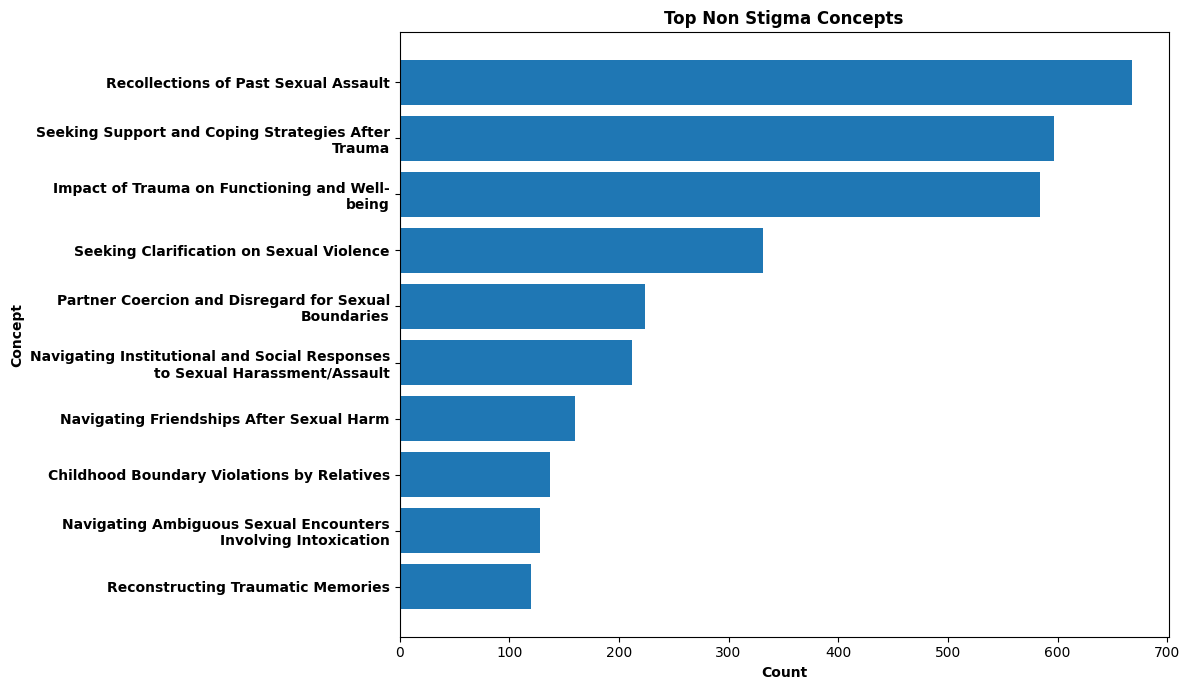

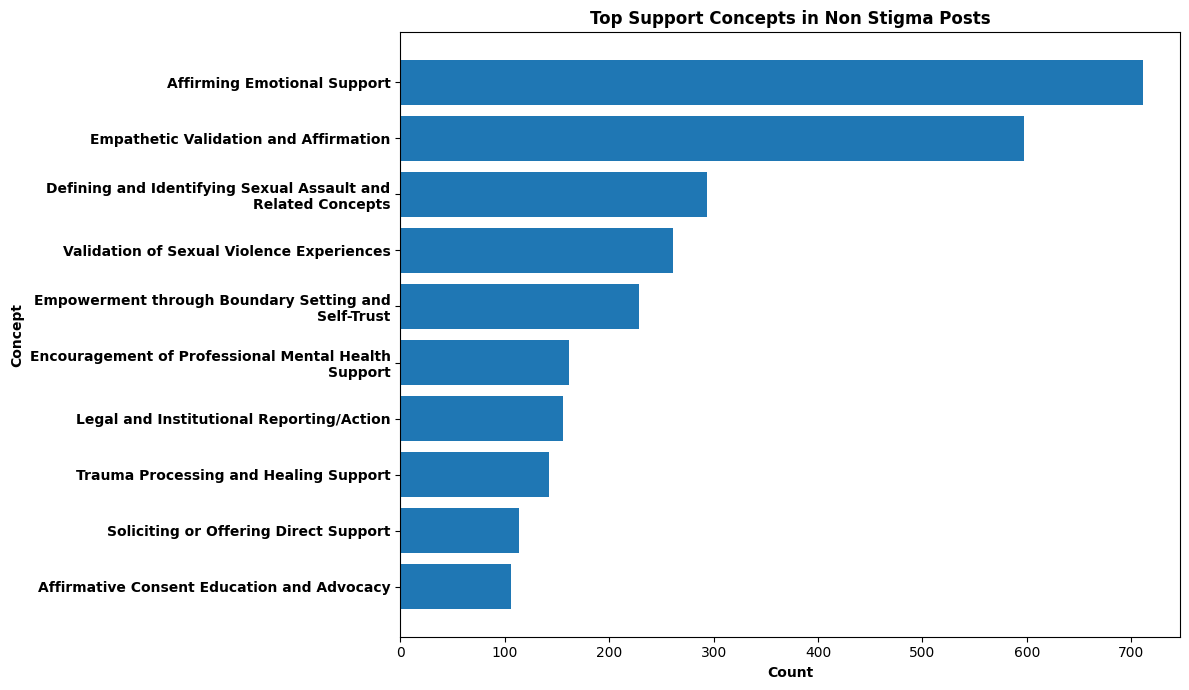

In [ ]:
concept_barplot(
    non_stigma_post_concept_summary,
    "Top Non Stigma Concepts",
    top_n=10,
    save_path="/content/lloom_gemini_sv_outputs_nonstigma/top_non_stigma_concepts.pdf"
)

concept_barplot(
    non_stigma_support_concept_summary,
    "Top Support Concepts in Non Stigma Posts",
    top_n=10,
    save_path="/content/lloom_gemini_sv_outputs_nonstigma/top_non_stigma_support_concepts.pdf"
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil

src = "/content/lloom_gemini_sv_outputs_nonstigma"
dst = "/content/drive/MyDrive/LLooM_ops_non_stigma"

shutil.copytree(src, dst)

'/content/drive/MyDrive/LLooM_ops_non_stigma'

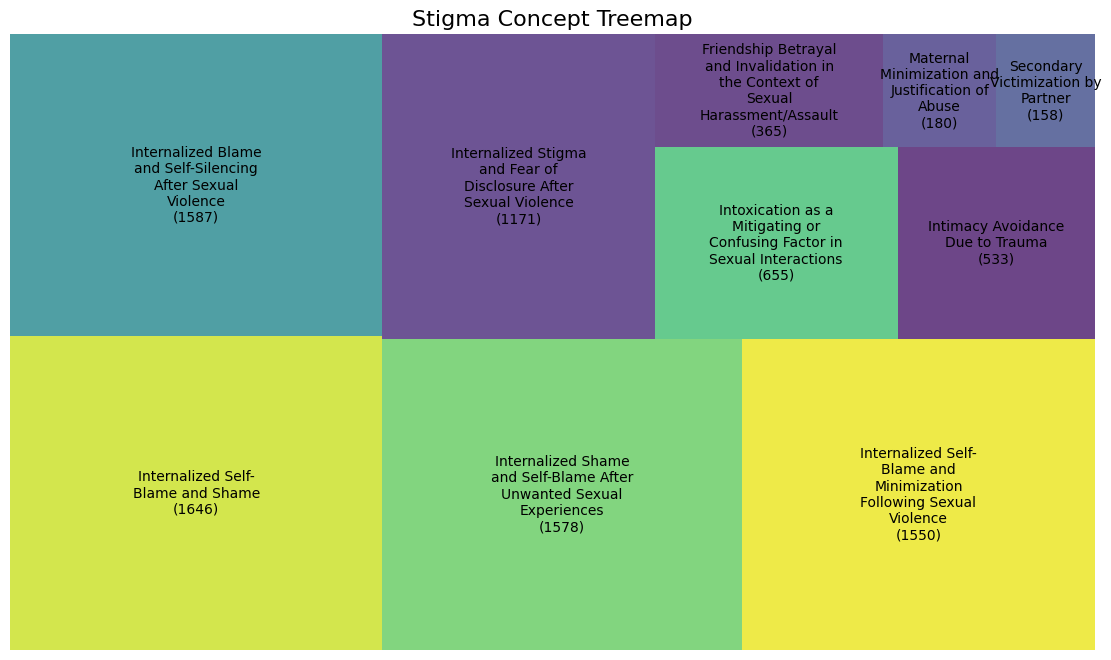

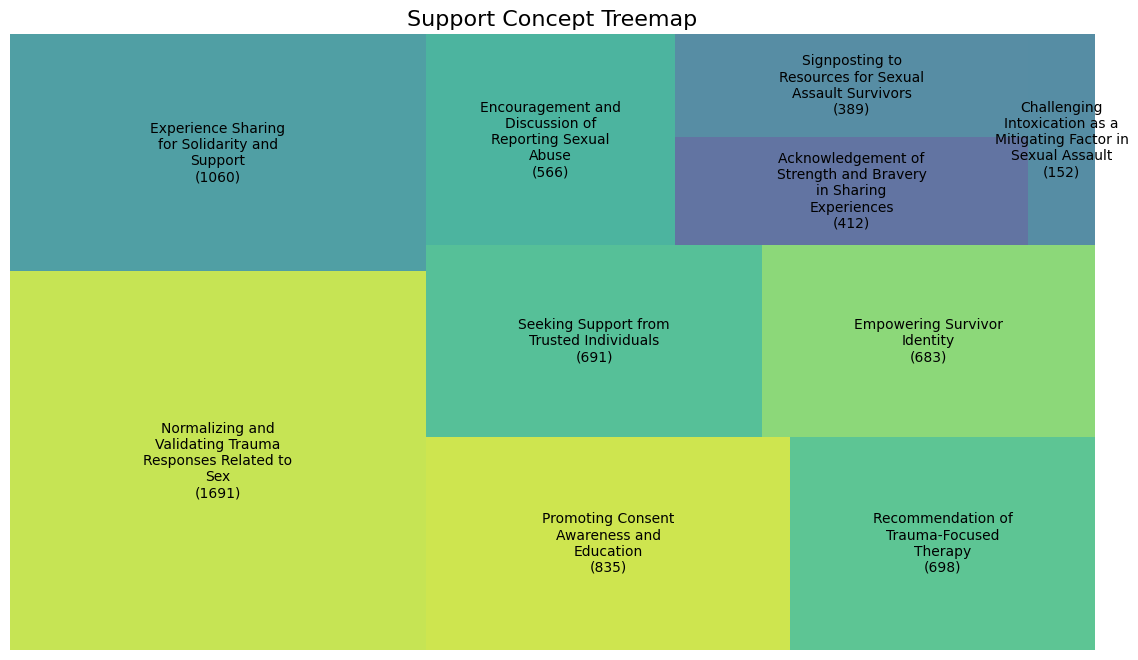

In [ ]:
def concept_treemap(df, title, top_n=10):
    plot_df = df.sort_values("matched_count", ascending=False).head(top_n).copy()

    labels = [
        "\n".join(textwrap.wrap(str(name), width=20)) + f"\n({count})"
        for name, count in zip(plot_df["concept_name"], plot_df["matched_count"])
    ]

    plt.figure(figsize=(14, 8))
    squarify.plot(
        sizes=plot_df["matched_count"],
        label=labels,
        alpha=0.8
    )
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

concept_treemap(stigma_concept_summary, "Stigma Concept Treemap", top_n=10)
concept_treemap(support_concept_summary, "Support Concept Treemap", top_n=10)

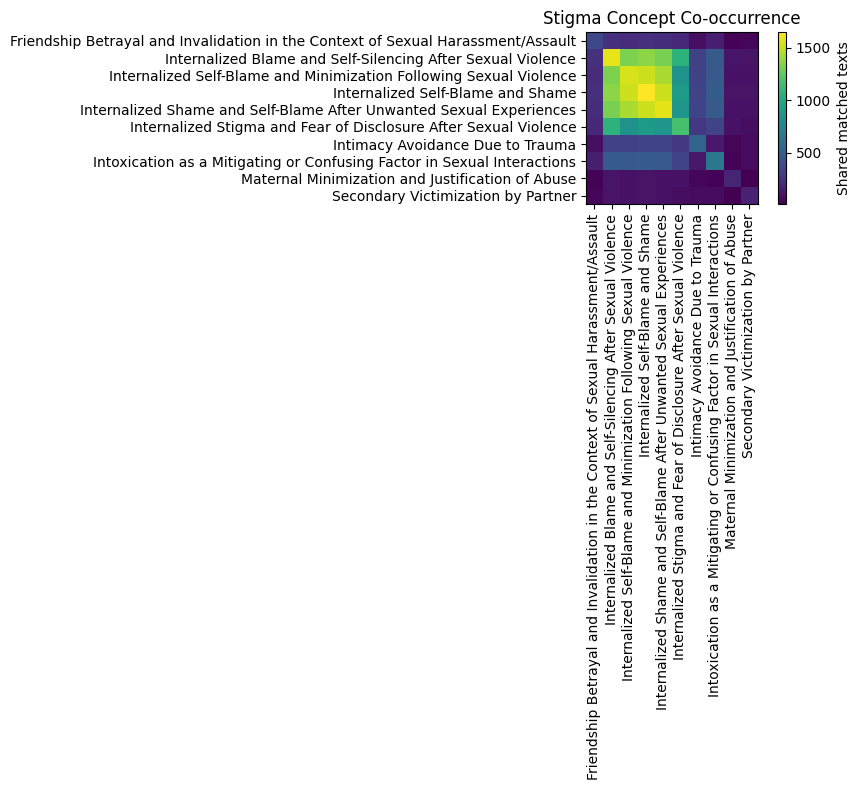

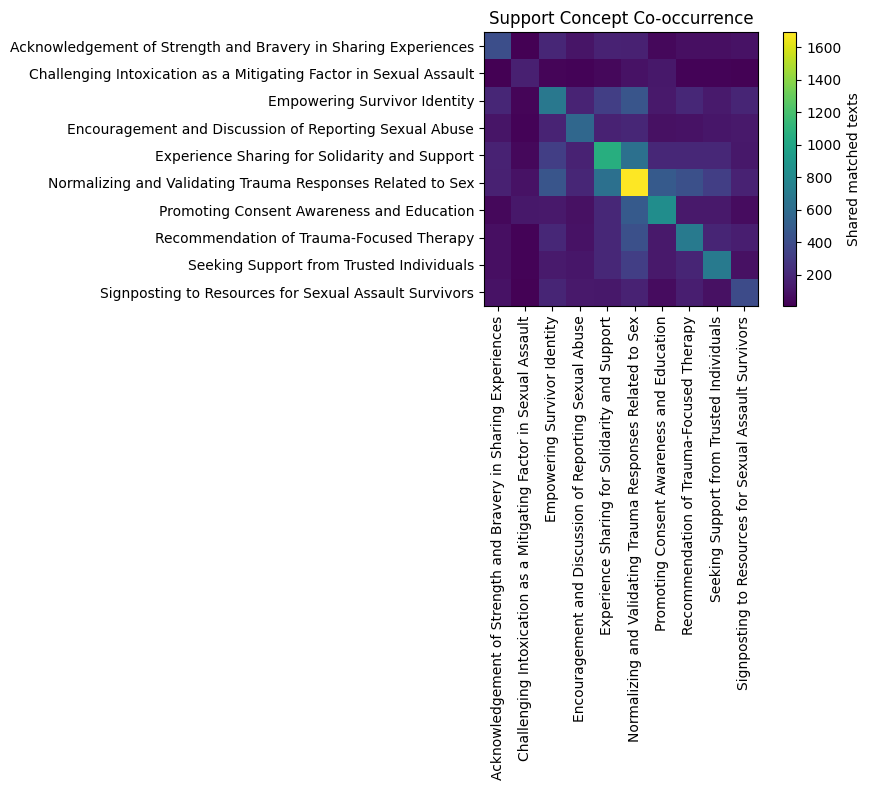

In [ ]:
def concept_cooccurrence_heatmap(scores_df, title, top_n=10):
    matched = scores_df[scores_df["match"] == 1].copy()

    top_concepts = matched["concept_name"].value_counts().head(top_n).index.tolist()
    matched = matched[matched["concept_name"].isin(top_concepts)]

    binary = pd.crosstab(matched["orig_index"], matched["concept_name"])
    cooc = binary.T.dot(binary)

    plt.figure(figsize=(10, 8))
    plt.imshow(cooc, interpolation="nearest")
    plt.colorbar(label="Shared matched texts")
    plt.xticks(range(len(cooc.columns)), cooc.columns, rotation=90)
    plt.yticks(range(len(cooc.index)), cooc.index)
    plt.title(title)
    plt.tight_layout()
    plt.show()

concept_cooccurrence_heatmap(stigma_scores, "Stigma Concept Co-occurrence")
concept_cooccurrence_heatmap(support_scores, "Support Concept Co-occurrence")